In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt

from src.visualizacao import aplicar_estilo_dark, estilizar_grafico, adicionar_valores_barras, COR_VERMELHO, COR_AZUL

aplicar_estilo_dark()

In [2]:
df = pd.read_csv("../data/processed/dataset_final_resumo_limpo.csv")

top_kd = df.groupby("Fighter")["KD"].sum().sort_values(ascending=False).head(10)

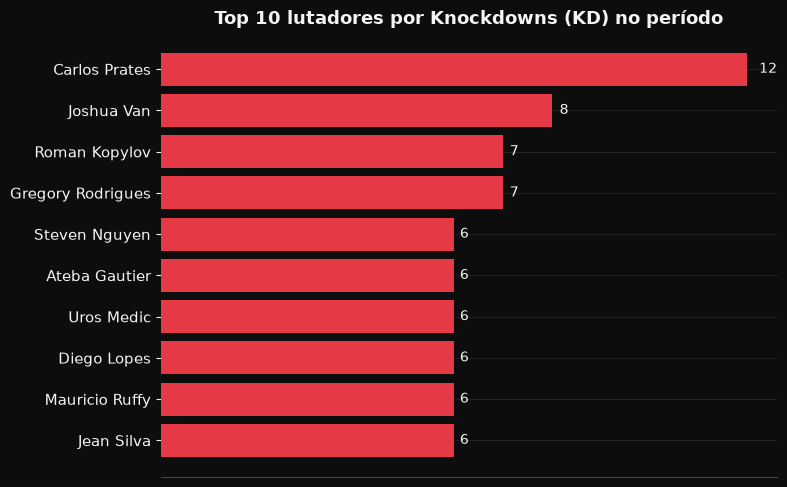

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.barh(top_kd.index[::-1], top_kd.values[::-1], color=COR_VERMELHO)

adicionar_valores_barras(ax, barras)
estilizar_grafico(ax, "Top 10 lutadores por Knockdowns (KD) no período")

plt.tight_layout()
plt.savefig("../figures/top10_kd.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

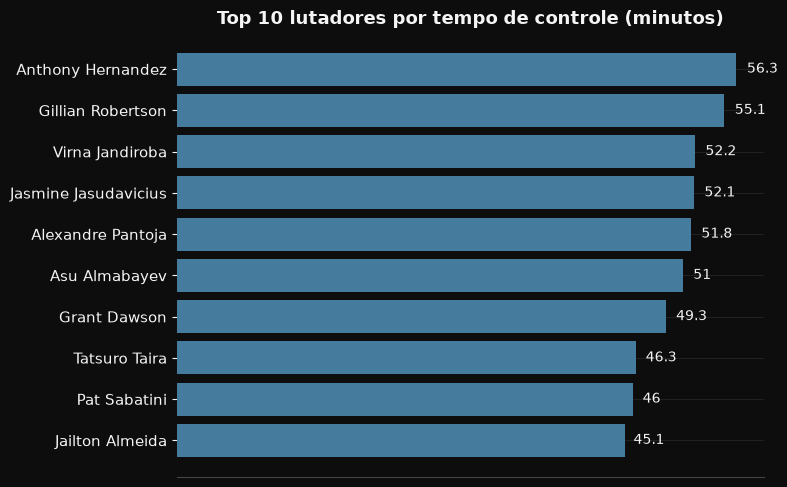

In [4]:
df_proc = pd.read_csv("../data/processed/dataset_24eventos_resumo_limpo.csv") if False else pd.read_csv("../data/processed/dataset_final_resumo_limpo.csv")

top_ctrl = df_proc.groupby("Fighter")["Ctrl_seconds"].sum().sort_values(ascending=False).head(10)
top_ctrl_min = (top_ctrl / 60).round(1)  # converter para minutos, mais legível

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.barh(top_ctrl_min.index[::-1], top_ctrl_min.values[::-1], color=COR_AZUL)

adicionar_valores_barras(ax, barras)
estilizar_grafico(ax, "Top 10 lutadores por tempo de controle (minutos)")

plt.tight_layout()
plt.savefig("../figures/top10_ctrl.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()